In [1]:
import os
## change the directory to the wholistic_registration code dir, so that we can import the modules in utils
os.chdir('/home/cyf/wbi/Virginia/code_for_paper/wholistic_registration/src/wholistic_registration')
import cupy as cp
cp.cuda.Device(0).use()
from utils import IO
from utils import calFlowCrossResolution, calFlow3d_Wei_v1
from utils import registration
from utils import option
from utils import preprocess as prep
from utils import mask
from utils import  visualization
import numpy as np
gut_mov_Path     = "/home/cyf/wbi/Virginia/registrated_data/f260201/gut/raw/260201_test1_0_00002_TZCXY.ome.tif"
ventral_mov_Path = "/home/cyf/wbi/Virginia/registrated_data/f260201/ventral/raw/260201_test1_0_00003_TZCXY.ome.tif"
dorsal_mov_Path  = "/home/cyf/wbi/Virginia/registrated_data/f260201/dorsal/raw/260201_test1_0_00005_TZCXY.ome.tif"
gut_ref_Path     = "/home/cyf/wbi/Virginia/registrated_data/f260201/gut/anat/260201_test1_0_00002_TZCXY.ome.tif"
ventral_ref_Path = "/home/cyf/wbi/Virginia/registrated_data/f260201/ventral/anat/260201_test1_0_00002_TZCXY.ome.tif"
dorsal_ref_Path  = "/home/cyf/wbi/Virginia/registrated_data/f260201/dorsal/anat/260201_test1_0_00004_TZCXY.ome.tif"

CuPy is available with CUDA - using GPU acceleration


In [2]:
from utils import calFlowCrossResolution
gut_ref,gut_ref_desc = IO.readTiff(gut_ref_Path)
gut_mov,gut_mov_desc = IO.readTiff(gut_mov_Path)
# print(gut_ref_desc)
gut_ref = gut_ref.transpose(1,2,0)
gut_mov = gut_mov.transpose(0,2,3,1)
### see the slice 86, 87,88
### use the whole image as the groundtruth
#initial the pyramid parameters
# slices = [26,27,28,29,30,31,32,33]
slice = 40
initial_loss_base =[]
initial_loss_method =[]
eventual_loss_base = []
eventual_loss_method = []
option['r']=5
option['layer']=3
option['iter']=10
option['movRange']=15.
option['tol']=1e-6
thresFactor= 5.
maskRange  = [5.,4000.]
smoothPenalty_raw=0.1
option['zRatio'] = 5
option['zRatio_HR']= 1
gut_ref_sample =gut_mov[2,:,:,40:120]
H_ref_layer = calFlowCrossResolution.generate_continuous_H_gpu(gut_ref_sample, zRatio=1)
option['mask_ref']=mask.getMask(gut_ref_sample,thresFactor)
option['mask_ref']=mask.bwareafilt3_wei(option['mask_ref'],maskRange)
# visualization.visualize_3d_image(option['mask_ref'],title = "reference mask",autocontrast=False)
# option['mask_ref']=np.zeros_like(gut_ref_sample)
Pnltfactor = prep.getSmPnltNormFctr(gut_ref_sample, option)
smoothPenalty=Pnltfactor*smoothPenalty_raw
option['smoothPenalty']=smoothPenalty
option["wrong_region_enable"] = False

j=0
for frame in range(3,5):
    if frame != 0:
        gut_mov_sample = gut_mov[frame,:,:,40:120]
        for i in range(40,60):
            slices = [i,i+5,i+10,i+15]
            gut_moving = gut_mov_sample[:,:,slices]
            # option['mask_mov']=mask.getMask(gut_moving,thresFactor)
            # option['mask_mov']=mask.bwareafilt3_wei(option['mask_mov'],maskRange)
            # visualization.visualize_2d_image(option['mask_mov'],title = "reference mask",autocontrast=False)
            option['mask_mov']=np.zeros_like(gut_moving,dtype=bool)
            H, W, D = gut_moving.shape
            X, Y, Z = np.indices((H, W, D))
            delta = option['zRatio'] / option['zRatio_HR']

            #############baseline
            K = len(slices)
            yy, xx = np.meshgrid(
                np.arange(H, dtype=np.float32),
                np.arange(W, dtype=np.float32),
                indexing="ij"
            )
            phase_init = np.zeros((H, W, K, 3), dtype=np.float32)
            phase_init[..., 0] = yy[:, :, None]
            phase_init[..., 1] = xx[:, :, None]
            phase_init[..., 2] = np.asarray(slices, dtype=np.float32)[None, None, :]
            option["phase"]=phase_init
            phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion_v2(gut_moving, gut_ref_sample,option,verbose =False)
            data_mov_init = calFlowCrossResolution.apply_H_to_matrix_gpu(phase_init, H_ref_layer)
            data_mov_even = calFlowCrossResolution.apply_H_to_matrix_gpu(phase_new, H_ref_layer)
            initial_base = np.mean(np.abs((data_mov_init.get()-gut_moving)))
            eventual_base = np.mean(np.abs((data_mov_even.get()-gut_moving)))


            phase_init, z_map = calFlowCrossResolution.FindInitPhase_stack_robust_mse(
                data_mov=gut_moving,       # shape (H, W, K)
                data_ref=gut_ref_sample,         # shape (H, W, Z)
                patch_size=200,
                overlap=0.4,
                delta_ref_idx=delta,      # scalar is okay
                regularization_lambda_xy=2,
                regularization_lambda_stack=2,
                regularization_iters=50,
            )
            option["phase"]=phase_init
            phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion_v2(gut_moving, gut_ref_sample,option,verbose =False)
            data_mov_init = calFlowCrossResolution.apply_H_to_matrix_gpu(phase_init, H_ref_layer)
            data_mov_even = calFlowCrossResolution.apply_H_to_matrix_gpu(phase_new, H_ref_layer)
            initial_method = np.mean(np.abs((data_mov_init.get()-gut_moving)))
            eventual_method = np.mean(np.abs((data_mov_even.get()-gut_moving)))

            initial_loss_base.append(initial_base)
            eventual_loss_base.append(eventual_base)
            initial_loss_method.append(initial_method)
            eventual_loss_method.append(eventual_method)

            print(f"exp[{j}]:, initial_base: {initial_base:.4f}, eventual_base: {eventual_base:.4f}, initial_method: {initial_method:.4f}, eventual_method: {eventual_method:.4f}")
            j += 1


exp[0]:, initial_base: 225.8294, eventual_base: 177.6668, initial_method: 213.4172, eventual_method: 177.6769
exp[1]:, initial_base: 223.2109, eventual_base: 176.2936, initial_method: 212.0259, eventual_method: 176.2986
exp[2]:, initial_base: 220.0379, eventual_base: 174.6871, initial_method: 211.9590, eventual_method: 174.7367
exp[3]:, initial_base: 216.7305, eventual_base: 173.1580, initial_method: 214.5280, eventual_method: 173.1394
exp[4]:, initial_base: 213.7338, eventual_base: 171.2859, initial_method: 218.9074, eventual_method: 171.2744
exp[5]:, initial_base: 210.7045, eventual_base: 169.3184, initial_method: 221.0554, eventual_method: 169.3186
exp[6]:, initial_base: 207.4919, eventual_base: 167.5339, initial_method: 224.1530, eventual_method: 167.6231
exp[7]:, initial_base: 204.0941, eventual_base: 165.2983, initial_method: 227.9123, eventual_method: 165.4048
exp[8]:, initial_base: 200.4872, eventual_base: 163.3723, initial_method: 235.1085, eventual_method: 163.3768
exp[9]:, i

KeyboardInterrupt: 

In [ ]:
visualization.visualize_2d_image(gut_moving[:,:,0],title = "reference image",autocontrast=True)
visualization.visualize_2d_image(data_mov_init[:,:,0].get(),title = "reference mask",autocontrast=False)
visualization.visualize_2d_image(data_mov_even[:,:,0].get(),title = "reference mask",autocontrast=False)

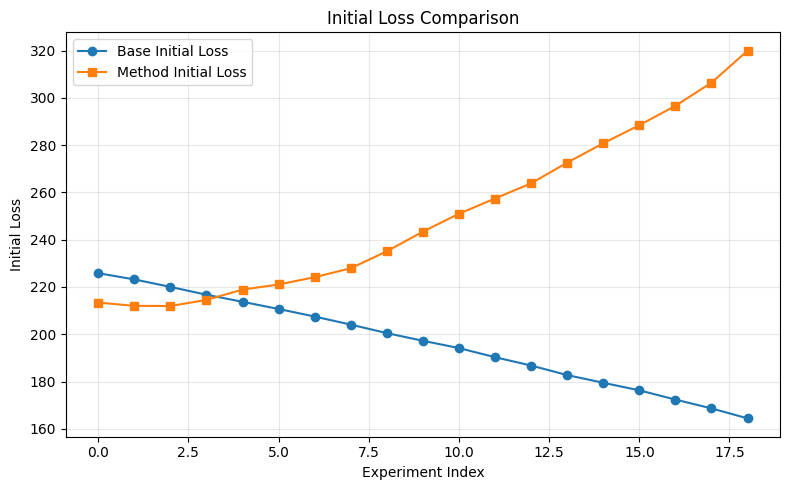

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 原始数据 =====
data = [
(225.8294,213.4172),
(223.2109,212.0259),
(220.0379,211.9590),
(216.7305,214.5280),
(213.7338,218.9074),
(210.7045,221.0554),
(207.4919,224.1530),
(204.0941,227.9123),
(200.4872,235.1085),
(197.2491,243.4087),
(194.1597,250.9936),
(190.3055,257.4282),
(186.7806,263.8511),
(182.7364,272.6019),
(179.4823,280.7930),
(176.2913,288.4458),
(172.3799,296.6282),
(168.6484,306.4262),
(164.4407,319.9464),

]

# ===== 拆分 =====
initial_base = [d[0] for d in data]
initial_method = [d[1] for d in data]

x = np.arange(len(data))

# ===== 作图 =====
plt.figure(figsize=(8,5))

plt.plot(x, initial_base, marker='o', label='Base Initial Loss')
plt.plot(x, initial_method, marker='s', label='Method Initial Loss')

plt.xlabel('Experiment Index')
plt.ylabel('Initial Loss')
plt.title('Initial Loss Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

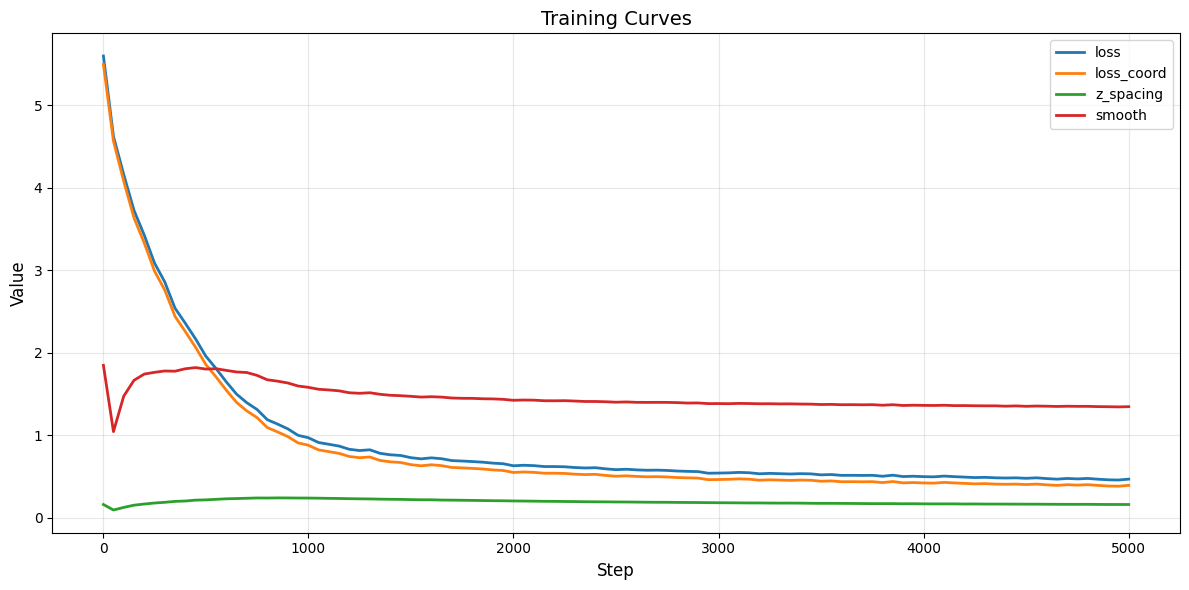

In [ ]:
import re
import matplotlib.pyplot as plt

log_text = """
step 00001 | loss=5.5972 | loss_coord=5.4968 | smooth=1.8476 | z_spacing=0.1601 | disp_mae=1.8323 | z_disp_mae=0.5144 | coord_mae=1.8323 | z_coord_mae=0.5144
step 00050 | loss=4.6224 | loss_coord=4.5655 | smooth=1.0437 | z_spacing=0.0932 | disp_mae=1.5218 | z_disp_mae=0.4611 | coord_mae=1.5218 | z_coord_mae=0.4611
step 00100 | loss=4.1603 | loss_coord=4.0804 | smooth=1.4737 | z_spacing=0.1248 | disp_mae=1.3601 | z_disp_mae=0.4522 | coord_mae=1.3601 | z_coord_mae=0.4522
step 00150 | loss=3.7268 | loss_coord=3.6359 | smooth=1.6657 | z_spacing=0.1518 | disp_mae=1.2120 | z_disp_mae=0.4405 | coord_mae=1.2120 | z_coord_mae=0.4405
step 00200 | loss=3.4263 | loss_coord=3.3309 | smooth=1.7412 | z_spacing=0.1658 | disp_mae=1.1103 | z_disp_mae=0.4332 | coord_mae=1.1103 | z_coord_mae=0.4332
step 00250 | loss=3.0882 | loss_coord=2.9911 | smooth=1.7624 | z_spacing=0.1782 | disp_mae=0.9970 | z_disp_mae=0.4266 | coord_mae=0.9970 | z_coord_mae=0.4266
step 00300 | loss=2.8588 | loss_coord=2.7605 | smooth=1.7789 | z_spacing=0.1867 | disp_mae=0.9202 | z_disp_mae=0.4175 | coord_mae=0.9202 | z_coord_mae=0.4175
step 00350 | loss=2.5406 | loss_coord=2.4419 | smooth=1.7762 | z_spacing=0.1979 | disp_mae=0.8140 | z_disp_mae=0.4131 | coord_mae=0.8140 | z_coord_mae=0.4131
step 00400 | loss=2.3581 | loss_coord=2.2577 | smooth=1.8058 | z_spacing=0.2024 | disp_mae=0.7526 | z_disp_mae=0.4089 | coord_mae=0.7526 | z_coord_mae=0.4089
step 00450 | loss=2.1689 | loss_coord=2.0673 | smooth=1.8200 | z_spacing=0.2131 | disp_mae=0.6891 | z_disp_mae=0.3966 | coord_mae=0.6891 | z_coord_mae=0.3966
step 00500 | loss=1.9592 | loss_coord=1.8583 | smooth=1.8021 | z_spacing=0.2163 | disp_mae=0.6194 | z_disp_mae=0.3921 | coord_mae=0.6194 | z_coord_mae=0.3921
step 00550 | loss=1.8088 | loss_coord=1.7074 | smooth=1.8066 | z_spacing=0.2227 | disp_mae=0.5691 | z_disp_mae=0.3835 | coord_mae=0.5691 | z_coord_mae=0.3835
step 00600 | loss=1.6472 | loss_coord=1.5464 | smooth=1.7862 | z_spacing=0.2294 | disp_mae=0.5155 | z_disp_mae=0.3786 | coord_mae=0.5155 | z_coord_mae=0.3786
step 00650 | loss=1.4984 | loss_coord=1.3984 | smooth=1.7669 | z_spacing=0.2323 | disp_mae=0.4661 | z_disp_mae=0.3707 | coord_mae=0.4661 | z_coord_mae=0.3707
step 00700 | loss=1.3943 | loss_coord=1.2945 | smooth=1.7603 | z_spacing=0.2359 | disp_mae=0.4315 | z_disp_mae=0.3639 | coord_mae=0.4315 | z_coord_mae=0.3639
step 00750 | loss=1.3123 | loss_coord=1.2140 | smooth=1.7257 | z_spacing=0.2393 | disp_mae=0.4047 | z_disp_mae=0.3584 | coord_mae=0.4047 | z_coord_mae=0.3584
step 00800 | loss=1.1884 | loss_coord=1.0929 | smooth=1.6722 | z_spacing=0.2386 | disp_mae=0.3643 | z_disp_mae=0.3514 | coord_mae=0.3643 | z_coord_mae=0.3514
step 00850 | loss=1.1351 | loss_coord=1.0404 | smooth=1.6555 | z_spacing=0.2402 | disp_mae=0.3468 | z_disp_mae=0.3442 | coord_mae=0.3468 | z_coord_mae=0.3442
step 00900 | loss=1.0774 | loss_coord=0.9838 | smooth=1.6334 | z_spacing=0.2397 | disp_mae=0.3279 | z_disp_mae=0.3386 | coord_mae=0.3279 | z_coord_mae=0.3386
step 00950 | loss=0.9986 | loss_coord=0.9068 | smooth=1.5967 | z_spacing=0.2387 | disp_mae=0.3023 | z_disp_mae=0.3326 | coord_mae=0.3023 | z_coord_mae=0.3326
step 01000 | loss=0.9698 | loss_coord=0.8789 | smooth=1.5807 | z_spacing=0.2382 | disp_mae=0.2930 | z_disp_mae=0.3261 | coord_mae=0.2930 | z_coord_mae=0.3261
step 01050 | loss=0.9117 | loss_coord=0.8220 | smooth=1.5573 | z_spacing=0.2367 | disp_mae=0.2740 | z_disp_mae=0.3202 | coord_mae=0.2740 | z_coord_mae=0.3202
step 01100 | loss=0.8902 | loss_coord=0.8010 | smooth=1.5490 | z_spacing=0.2346 | disp_mae=0.2670 | z_disp_mae=0.3144 | coord_mae=0.2670 | z_coord_mae=0.3144
step 01150 | loss=0.8685 | loss_coord=0.7799 | smooth=1.5382 | z_spacing=0.2332 | disp_mae=0.2600 | z_disp_mae=0.3093 | coord_mae=0.2600 | z_coord_mae=0.3093
step 01200 | loss=0.8294 | loss_coord=0.7421 | smooth=1.5148 | z_spacing=0.2306 | disp_mae=0.2474 | z_disp_mae=0.3036 | coord_mae=0.2474 | z_coord_mae=0.3036
step 01250 | loss=0.8143 | loss_coord=0.7275 | smooth=1.5083 | z_spacing=0.2289 | disp_mae=0.2425 | z_disp_mae=0.2986 | coord_mae=0.2425 | z_coord_mae=0.2986
step 01300 | loss=0.8233 | loss_coord=0.7361 | smooth=1.5151 | z_spacing=0.2276 | disp_mae=0.2454 | z_disp_mae=0.2940 | coord_mae=0.2454 | z_coord_mae=0.2940
step 01350 | loss=0.7804 | loss_coord=0.6943 | smooth=1.4961 | z_spacing=0.2251 | disp_mae=0.2314 | z_disp_mae=0.2886 | coord_mae=0.2314 | z_coord_mae=0.2886
step 01400 | loss=0.7627 | loss_coord=0.6773 | smooth=1.4843 | z_spacing=0.2235 | disp_mae=0.2258 | z_disp_mae=0.2835 | coord_mae=0.2258 | z_coord_mae=0.2835
step 01450 | loss=0.7546 | loss_coord=0.6695 | smooth=1.4794 | z_spacing=0.2223 | disp_mae=0.2232 | z_disp_mae=0.2790 | coord_mae=0.2232 | z_coord_mae=0.2790
step 01500 | loss=0.7279 | loss_coord=0.6434 | smooth=1.4717 | z_spacing=0.2195 | disp_mae=0.2145 | z_disp_mae=0.2743 | coord_mae=0.2145 | z_coord_mae=0.2743
step 01550 | loss=0.7134 | loss_coord=0.6293 | smooth=1.4625 | z_spacing=0.2176 | disp_mae=0.2098 | z_disp_mae=0.2696 | coord_mae=0.2098 | z_coord_mae=0.2696
step 01600 | loss=0.7259 | loss_coord=0.6417 | smooth=1.4668 | z_spacing=0.2175 | disp_mae=0.2139 | z_disp_mae=0.2660 | coord_mae=0.2139 | z_coord_mae=0.2660
step 01650 | loss=0.7151 | loss_coord=0.6313 | smooth=1.4623 | z_spacing=0.2142 | disp_mae=0.2104 | z_disp_mae=0.2619 | coord_mae=0.2104 | z_coord_mae=0.2619
step 01700 | loss=0.6925 | loss_coord=0.6092 | smooth=1.4514 | z_spacing=0.2131 | disp_mae=0.2031 | z_disp_mae=0.2570 | coord_mae=0.2031 | z_coord_mae=0.2570
step 01750 | loss=0.6871 | loss_coord=0.6042 | smooth=1.4476 | z_spacing=0.2116 | disp_mae=0.2014 | z_disp_mae=0.2536 | coord_mae=0.2014 | z_coord_mae=0.2536
step 01800 | loss=0.6808 | loss_coord=0.5980 | smooth=1.4471 | z_spacing=0.2100 | disp_mae=0.1993 | z_disp_mae=0.2499 | coord_mae=0.1993 | z_coord_mae=0.2499
step 01850 | loss=0.6732 | loss_coord=0.5907 | smooth=1.4420 | z_spacing=0.2081 | disp_mae=0.1969 | z_disp_mae=0.2464 | coord_mae=0.1969 | z_coord_mae=0.2464
step 01900 | loss=0.6616 | loss_coord=0.5793 | smooth=1.4403 | z_spacing=0.2062 | disp_mae=0.1931 | z_disp_mae=0.2422 | coord_mae=0.1931 | z_coord_mae=0.2422
step 01950 | loss=0.6546 | loss_coord=0.5726 | smooth=1.4351 | z_spacing=0.2051 | disp_mae=0.1909 | z_disp_mae=0.2392 | coord_mae=0.1909 | z_coord_mae=0.2392
step 02000 | loss=0.6296 | loss_coord=0.5483 | smooth=1.4235 | z_spacing=0.2032 | disp_mae=0.1828 | z_disp_mae=0.2346 | coord_mae=0.1828 | z_coord_mae=0.2346
step 02050 | loss=0.6359 | loss_coord=0.5545 | smooth=1.4267 | z_spacing=0.2019 | disp_mae=0.1848 | z_disp_mae=0.2317 | coord_mae=0.1848 | z_coord_mae=0.2317
step 02100 | loss=0.6313 | loss_coord=0.5500 | smooth=1.4252 | z_spacing=0.2005 | disp_mae=0.1833 | z_disp_mae=0.2293 | coord_mae=0.1833 | z_coord_mae=0.2293
step 02150 | loss=0.6202 | loss_coord=0.5394 | smooth=1.4181 | z_spacing=0.1988 | disp_mae=0.1798 | z_disp_mae=0.2258 | coord_mae=0.1798 | z_coord_mae=0.2258
step 02200 | loss=0.6201 | loss_coord=0.5393 | smooth=1.4176 | z_spacing=0.1981 | disp_mae=0.1798 | z_disp_mae=0.2223 | coord_mae=0.1798 | z_coord_mae=0.2223
step 02250 | loss=0.6175 | loss_coord=0.5367 | smooth=1.4189 | z_spacing=0.1966 | disp_mae=0.1789 | z_disp_mae=0.2197 | coord_mae=0.1789 | z_coord_mae=0.2197
step 02300 | loss=0.6083 | loss_coord=0.5278 | smooth=1.4143 | z_spacing=0.1957 | disp_mae=0.1759 | z_disp_mae=0.2166 | coord_mae=0.1759 | z_coord_mae=0.2166
step 02350 | loss=0.6030 | loss_coord=0.5229 | smooth=1.4091 | z_spacing=0.1938 | disp_mae=0.1743 | z_disp_mae=0.2138 | coord_mae=0.1743 | z_coord_mae=0.2138
step 02400 | loss=0.6061 | loss_coord=0.5260 | smooth=1.4090 | z_spacing=0.1930 | disp_mae=0.1753 | z_disp_mae=0.2118 | coord_mae=0.1753 | z_coord_mae=0.2118
step 02450 | loss=0.5924 | loss_coord=0.5125 | smooth=1.4058 | z_spacing=0.1922 | disp_mae=0.1708 | z_disp_mae=0.2083 | coord_mae=0.1708 | z_coord_mae=0.2083
step 02500 | loss=0.5825 | loss_coord=0.5029 | smooth=1.4004 | z_spacing=0.1910 | disp_mae=0.1676 | z_disp_mae=0.2059 | coord_mae=0.1676 | z_coord_mae=0.2059
step 02550 | loss=0.5876 | loss_coord=0.5079 | smooth=1.4035 | z_spacing=0.1906 | disp_mae=0.1693 | z_disp_mae=0.2038 | coord_mae=0.1693 | z_coord_mae=0.2038
step 02600 | loss=0.5800 | loss_coord=0.5006 | smooth=1.3988 | z_spacing=0.1893 | disp_mae=0.1669 | z_disp_mae=0.2007 | coord_mae=0.1669 | z_coord_mae=0.2007
step 02650 | loss=0.5754 | loss_coord=0.4961 | smooth=1.3982 | z_spacing=0.1880 | disp_mae=0.1654 | z_disp_mae=0.1989 | coord_mae=0.1654 | z_coord_mae=0.1989
step 02700 | loss=0.5768 | loss_coord=0.4975 | smooth=1.3986 | z_spacing=0.1871 | disp_mae=0.1658 | z_disp_mae=0.1966 | coord_mae=0.1658 | z_coord_mae=0.1966
step 02750 | loss=0.5731 | loss_coord=0.4939 | smooth=1.3981 | z_spacing=0.1869 | disp_mae=0.1646 | z_disp_mae=0.1943 | coord_mae=0.1646 | z_coord_mae=0.1943
step 02800 | loss=0.5659 | loss_coord=0.4868 | smooth=1.3954 | z_spacing=0.1854 | disp_mae=0.1623 | z_disp_mae=0.1919 | coord_mae=0.1623 | z_coord_mae=0.1919
step 02850 | loss=0.5619 | loss_coord=0.4832 | smooth=1.3900 | z_spacing=0.1847 | disp_mae=0.1611 | z_disp_mae=0.1896 | coord_mae=0.1611 | z_coord_mae=0.1896
step 02900 | loss=0.5592 | loss_coord=0.4804 | smooth=1.3913 | z_spacing=0.1842 | disp_mae=0.1601 | z_disp_mae=0.1880 | coord_mae=0.1601 | z_coord_mae=0.1880
step 02950 | loss=0.5393 | loss_coord=0.4610 | smooth=1.3833 | z_spacing=0.1826 | disp_mae=0.1537 | z_disp_mae=0.1850 | coord_mae=0.1537 | z_coord_mae=0.1850
step 03000 | loss=0.5412 | loss_coord=0.4630 | smooth=1.3838 | z_spacing=0.1816 | disp_mae=0.1543 | z_disp_mae=0.1834 | coord_mae=0.1543 | z_coord_mae=0.1834
step 03050 | loss=0.5438 | loss_coord=0.4657 | smooth=1.3824 | z_spacing=0.1809 | disp_mae=0.1552 | z_disp_mae=0.1817 | coord_mae=0.1552 | z_coord_mae=0.1817
step 03100 | loss=0.5493 | loss_coord=0.4709 | smooth=1.3860 | z_spacing=0.1800 | disp_mae=0.1570 | z_disp_mae=0.1799 | coord_mae=0.1570 | z_coord_mae=0.1799
step 03150 | loss=0.5451 | loss_coord=0.4670 | smooth=1.3841 | z_spacing=0.1790 | disp_mae=0.1557 | z_disp_mae=0.1784 | coord_mae=0.1557 | z_coord_mae=0.1784
step 03200 | loss=0.5325 | loss_coord=0.4545 | smooth=1.3815 | z_spacing=0.1788 | disp_mae=0.1515 | z_disp_mae=0.1760 | coord_mae=0.1515 | z_coord_mae=0.1760
step 03250 | loss=0.5375 | loss_coord=0.4595 | smooth=1.3819 | z_spacing=0.1777 | disp_mae=0.1532 | z_disp_mae=0.1747 | coord_mae=0.1532 | z_coord_mae=0.1747
step 03300 | loss=0.5339 | loss_coord=0.4561 | smooth=1.3797 | z_spacing=0.1771 | disp_mae=0.1520 | z_disp_mae=0.1729 | coord_mae=0.1520 | z_coord_mae=0.1729
step 03350 | loss=0.5300 | loss_coord=0.4521 | smooth=1.3804 | z_spacing=0.1774 | disp_mae=0.1507 | z_disp_mae=0.1713 | coord_mae=0.1507 | z_coord_mae=0.1713
step 03400 | loss=0.5340 | loss_coord=0.4563 | smooth=1.3779 | z_spacing=0.1766 | disp_mae=0.1521 | z_disp_mae=0.1697 | coord_mae=0.1521 | z_coord_mae=0.1697
step 03450 | loss=0.5316 | loss_coord=0.4540 | smooth=1.3768 | z_spacing=0.1750 | disp_mae=0.1513 | z_disp_mae=0.1682 | coord_mae=0.1513 | z_coord_mae=0.1682
step 03500 | loss=0.5196 | loss_coord=0.4423 | smooth=1.3723 | z_spacing=0.1741 | disp_mae=0.1474 | z_disp_mae=0.1664 | coord_mae=0.1474 | z_coord_mae=0.1664
step 03550 | loss=0.5233 | loss_coord=0.4459 | smooth=1.3740 | z_spacing=0.1744 | disp_mae=0.1486 | z_disp_mae=0.1645 | coord_mae=0.1486 | z_coord_mae=0.1645
step 03600 | loss=0.5133 | loss_coord=0.4361 | smooth=1.3699 | z_spacing=0.1735 | disp_mae=0.1454 | z_disp_mae=0.1635 | coord_mae=0.1454 | z_coord_mae=0.1635
step 03650 | loss=0.5141 | loss_coord=0.4369 | smooth=1.3706 | z_spacing=0.1727 | disp_mae=0.1456 | z_disp_mae=0.1618 | coord_mae=0.1456 | z_coord_mae=0.1618
step 03700 | loss=0.5126 | loss_coord=0.4355 | smooth=1.3689 | z_spacing=0.1717 | disp_mae=0.1452 | z_disp_mae=0.1603 | coord_mae=0.1452 | z_coord_mae=0.1603
step 03750 | loss=0.5139 | loss_coord=0.4369 | smooth=1.3705 | z_spacing=0.1707 | disp_mae=0.1456 | z_disp_mae=0.1595 | coord_mae=0.1456 | z_coord_mae=0.1595
step 03800 | loss=0.5026 | loss_coord=0.4259 | smooth=1.3635 | z_spacing=0.1707 | disp_mae=0.1420 | z_disp_mae=0.1574 | coord_mae=0.1420 | z_coord_mae=0.1574
step 03850 | loss=0.5155 | loss_coord=0.4385 | smooth=1.3700 | z_spacing=0.1707 | disp_mae=0.1462 | z_disp_mae=0.1566 | coord_mae=0.1462 | z_coord_mae=0.1566
step 03900 | loss=0.4989 | loss_coord=0.4224 | smooth=1.3606 | z_spacing=0.1691 | disp_mae=0.1408 | z_disp_mae=0.1551 | coord_mae=0.1408 | z_coord_mae=0.1551
step 03950 | loss=0.5029 | loss_coord=0.4263 | smooth=1.3638 | z_spacing=0.1697 | disp_mae=0.1421 | z_disp_mae=0.1539 | coord_mae=0.1421 | z_coord_mae=0.1539
step 04000 | loss=0.4977 | loss_coord=0.4212 | smooth=1.3620 | z_spacing=0.1681 | disp_mae=0.1404 | z_disp_mae=0.1528 | coord_mae=0.1404 | z_coord_mae=0.1528
step 04050 | loss=0.4955 | loss_coord=0.4191 | smooth=1.3606 | z_spacing=0.1676 | disp_mae=0.1397 | z_disp_mae=0.1514 | coord_mae=0.1397 | z_coord_mae=0.1514
step 04100 | loss=0.5047 | loss_coord=0.4282 | smooth=1.3634 | z_spacing=0.1678 | disp_mae=0.1427 | z_disp_mae=0.1510 | coord_mae=0.1427 | z_coord_mae=0.1510
step 04150 | loss=0.4978 | loss_coord=0.4214 | smooth=1.3589 | z_spacing=0.1677 | disp_mae=0.1405 | z_disp_mae=0.1497 | coord_mae=0.1405 | z_coord_mae=0.1497
step 04200 | loss=0.4924 | loss_coord=0.4161 | smooth=1.3594 | z_spacing=0.1660 | disp_mae=0.1387 | z_disp_mae=0.1484 | coord_mae=0.1387 | z_coord_mae=0.1484
step 04250 | loss=0.4866 | loss_coord=0.4104 | smooth=1.3572 | z_spacing=0.1667 | disp_mae=0.1368 | z_disp_mae=0.1470 | coord_mae=0.1368 | z_coord_mae=0.1470
step 04300 | loss=0.4896 | loss_coord=0.4135 | smooth=1.3564 | z_spacing=0.1654 | disp_mae=0.1378 | z_disp_mae=0.1460 | coord_mae=0.1378 | z_coord_mae=0.1460
step 04350 | loss=0.4837 | loss_coord=0.4076 | smooth=1.3563 | z_spacing=0.1655 | disp_mae=0.1359 | z_disp_mae=0.1449 | coord_mae=0.1359 | z_coord_mae=0.1449
step 04400 | loss=0.4812 | loss_coord=0.4053 | smooth=1.3520 | z_spacing=0.1651 | disp_mae=0.1351 | z_disp_mae=0.1436 | coord_mae=0.1351 | z_coord_mae=0.1436
step 04450 | loss=0.4834 | loss_coord=0.4074 | smooth=1.3555 | z_spacing=0.1646 | disp_mae=0.1358 | z_disp_mae=0.1429 | coord_mae=0.1358 | z_coord_mae=0.1429
step 04500 | loss=0.4776 | loss_coord=0.4019 | smooth=1.3505 | z_spacing=0.1642 | disp_mae=0.1340 | z_disp_mae=0.1419 | coord_mae=0.1340 | z_coord_mae=0.1419
step 04550 | loss=0.4836 | loss_coord=0.4077 | smooth=1.3539 | z_spacing=0.1640 | disp_mae=0.1359 | z_disp_mae=0.1414 | coord_mae=0.1359 | z_coord_mae=0.1414
step 04600 | loss=0.4745 | loss_coord=0.3987 | smooth=1.3519 | z_spacing=0.1632 | disp_mae=0.1329 | z_disp_mae=0.1400 | coord_mae=0.1329 | z_coord_mae=0.1400
step 04650 | loss=0.4674 | loss_coord=0.3918 | smooth=1.3490 | z_spacing=0.1626 | disp_mae=0.1306 | z_disp_mae=0.1388 | coord_mae=0.1306 | z_coord_mae=0.1388
step 04700 | loss=0.4759 | loss_coord=0.4002 | smooth=1.3515 | z_spacing=0.1621 | disp_mae=0.1334 | z_disp_mae=0.1385 | coord_mae=0.1334 | z_coord_mae=0.1385
step 04750 | loss=0.4706 | loss_coord=0.3950 | smooth=1.3502 | z_spacing=0.1620 | disp_mae=0.1317 | z_disp_mae=0.1373 | coord_mae=0.1317 | z_coord_mae=0.1373
step 04800 | loss=0.4761 | loss_coord=0.4005 | smooth=1.3502 | z_spacing=0.1622 | disp_mae=0.1335 | z_disp_mae=0.1368 | coord_mae=0.1335 | z_coord_mae=0.1368
step 04850 | loss=0.4669 | loss_coord=0.3915 | smooth=1.3469 | z_spacing=0.1612 | disp_mae=0.1305 | z_disp_mae=0.1355 | coord_mae=0.1305 | z_coord_mae=0.1355
step 04900 | loss=0.4595 | loss_coord=0.3842 | smooth=1.3456 | z_spacing=0.1604 | disp_mae=0.1281 | z_disp_mae=0.1345 | coord_mae=0.1281 | z_coord_mae=0.1345
step 04950 | loss=0.4571 | loss_coord=0.3819 | smooth=1.3435 | z_spacing=0.1604 | disp_mae=0.1273 | z_disp_mae=0.1335 | coord_mae=0.1273 | z_coord_mae=0.1335
step 05000 | loss=0.4677 | loss_coord=0.3924 | smooth=1.3463 | z_spacing=0.1600 | disp_mae=0.1308 | z_disp_mae=0.1335 | coord_mae=0.1308 | z_coord_mae=0.1335
"""

# 解析日志
steps = []
loss_list = []
loss_coord_list = []
z_spacing_list = []
smooth_list = []

pattern = re.compile(r'step\s*(\d+) \| loss=([\d\.]+) \| loss_coord=([\d\.]+) \| smooth=([\d\.]+) \| z_spacing=([\d\.]+)')

for line in log_text.strip().splitlines():
    line = line.strip()
    if not line:
        continue
    m = pattern.match(line)
    if m:
        step = int(m.group(1))
        loss = float(m.group(2))
        loss_coord = float(m.group(3))
        smooth = float(m.group(4))
        z_spacing = float(m.group(5))

        steps.append(step)
        loss_list.append(loss)
        loss_coord_list.append(loss_coord)
        z_spacing_list.append(z_spacing)
        smooth_list.append(smooth)

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(steps, loss_list, label='loss', linewidth=2)
plt.plot(steps, loss_coord_list, label='loss_coord', linewidth=2)
plt.plot(steps, z_spacing_list, label='z_spacing', linewidth=2)
plt.plot(steps, smooth_list, label='smooth', linewidth=2)

plt.xlabel('Step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Training Curves', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()